In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science','bright'])
# plt.style.use(['science', 'std-colors'])
plt.rcParams.update({'figure.dpi': '150'})
mcolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
import matplotlib.pyplot as plt

plt.style.use(['no-latex']) 

layer 0, reshaping into 2x20
Loaded layer 0: W(2, 20), B(20,)
layer 1, reshaping into 20x20
Loaded layer 1: W(20, 20), B(20,)
layer 2, reshaping into 20x1
Loaded layer 2: W(20, 1), B(1,)


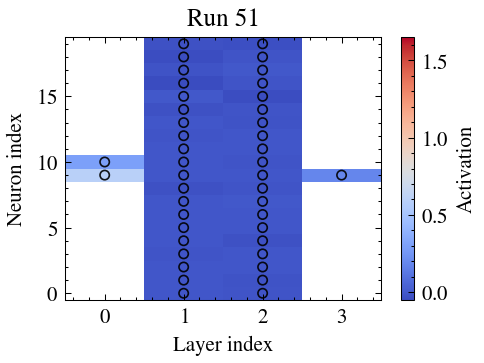

[0.6 0.3] →  [0.1859242]


In [2]:
import os

# --------------------------------------------
# Network architecture
# --------------------------------------------
layer_sizes = [2, 20, 20, 1]
NL = len(layer_sizes) -1 # number of layers
normalize = False


# --------------------------------------------
# Activation
# --------------------------------------------
def activation(x, alpha=0.01):
    """
    LeakyReLU equivalent in NumPy.
    x: input array or scalar
    alpha: slope for x < 0
    """
    return np.where(x >= 0, x, alpha * x)

# --------------------------------------------
# Load weights & biases
# --------------------------------------------
def load_layer_params(layer_idx, run):
    """Load weights and biases for one layer."""
    w_file = f"./weights/weights_eikonal/run{run}/weights_eikonal_run{run}_layer{layer_idx}.txt"
    b_file = f"./weights/weights_eikonal/run{run}/biases_eikonal_run{run}_layer{layer_idx}.txt"

    # Load weights & biases while skipping header lines starting with '#'
    W_flat = np.loadtxt(w_file, comments="#")
    B_flat = np.loadtxt(b_file, comments="#")

    fan_in, fan_out = layer_sizes[layer_idx], layer_sizes[layer_idx + 1]
    print(f"layer {layer_idx}, reshaping into {fan_in}x{fan_out}")
    # Reshape weights: (fan_in, fan_out)
    W = W_flat.reshape(fan_in, fan_out)
    B = B_flat.reshape(fan_out)
    return W, B



def model_chain(x,t,plot='no',run=None):
    # Load all layers
    W, B = [], []
    for l in range(NL):
        Wi, Bi = load_layer_params(l, run)
        W.append(Wi)
        B.append(Bi)
        print(f"Loaded layer {l}: W{Wi.shape}, B{Bi.shape}")

    # --------------------------------------------
    # Single trajectory evolution
    # --------------------------------------------
    z = [None] * (NL+1)
    # x_rand = 2.0 * np.random.rand() - 1.0   # random x in [-1, 1]
    x_rand = x
    t_fixed = t                           # fixed time

    z[0] = np.array([x_rand, t_fixed])
    if normalize:
        z[0] /= np.sum(np.abs(z[0]))


    # print(f"Layer {0} → z[{0}].shape = {z[0].shape}")
    for l in range(NL):

        zarg = z[l] @ W[l] + B[l]  

        # Apply tanh activation for all hidden layers (except last)
        if l < NL - 1:
            z[l + 1] = activation(zarg, 0.01)
        else:
            z[l + 1] = zarg  # last layer is linear (no activation)

        if normalize:
            znorm = np.sum(np.abs(z[l + 1])) + 1e-12
            z[l + 1] /= znorm
    
    # --------------------------------------------
    # Build activation matrix (always)
    # --------------------------------------------
    max_neurons = max(len(zl) for zl in z)
    z_mat = np.full((len(z), max_neurons), np.nan)
    
    if plot == 'yes':
        # --------------------------------------------
        # Visualization
        # --------------------------------------------
        # fig, axs = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

        # 1️⃣ Heatmap of average neuron activations (centered vertically)


        for i, zl in enumerate(z):
            n = len(zl)
            pad_top = (max_neurons - n) // 2
            pad_bottom = max_neurons - n - pad_top
            z_mat[i, pad_top:max_neurons - pad_bottom] = zl  # center each layer vertically
        # Overlay neuron circles on heatmap
        for layer_idx, zl in enumerate(z):
            n = len(zl)
            pad_top = (max_neurons - n) // 2
            neuron_indices = np.arange(pad_top, pad_top + n)

            plt.scatter(
                [layer_idx] * n,
                neuron_indices,
                facecolors='none',
                edgecolors='black',
                linewidths=0.8,
                s=20,
                alpha=0.9
            )



        im = plt.imshow(z_mat.T, aspect='auto', cmap='coolwarm',
                        origin='lower', vmin=-0.05, vmax=1.65)

        plt.colorbar(im, label='Activation')

        plt.xlabel("Layer index")
        plt.ylabel("Neuron index")
        plt.title(f"Run {run}")

        plt.tight_layout()
        plt.savefig(f"./figs/neurontrajectory_eikonal_run{run}.pdf", dpi=300)  # save the whole figure
        plt.show()

        print(f"{z[0]} →  {z[-1]}")




    return z[-1], z_mat


# _, _ = model_chain(0.6,0.3,plot='yes',run = 1) 
# _, _ = model_chain(0.6,0.3,plot='yes',run = 4) 
# _, _ = model_chain(0.6,0.3,plot='yes',run = 5) 
# _, _ = model_chain(0.6,0.3,plot='yes',run = 9) 
_, _ = model_chain(0.6,0.3,plot='yes',run = 51) 



In [3]:
# import fitz  # PyMuPDF

# def merge_two_pdfs_horizontally(pdf1_path, pdf2_path, output_pdf_path):
#     # Open PDFs
#     doc1 = fitz.open(pdf1_path)
#     doc2 = fitz.open(pdf2_path)

#     # Load first page of each
#     page1 = doc1.load_page(0)
#     page2 = doc2.load_page(0)

#     # Get page sizes
#     rect1 = page1.rect
#     rect2 = page2.rect

#     # New page size: sum of widths, max height
#     new_width = rect1.width + rect2.width
#     new_height = max(rect1.height, rect2.height)

#     # Create new PDF
#     new_doc = fitz.open()
#     new_page = new_doc.new_page(width=new_width, height=new_height)

#     # === Paste page1 on LEFT (centered vertically) ===
#     if rect1.height < new_height:
#         y_offset = (new_height - rect1.height) / 2
#     else:
#         y_offset = 0

#     new_page.show_pdf_page(
#         fitz.Rect(0, y_offset, rect1.width, y_offset + rect1.height),
#         doc1, 0
#     )

#     # === Paste page2 on RIGHT (centered vertically) ===
#     if rect2.height < new_height:
#         y_offset = (new_height - rect2.height) / 2
#     else:
#         y_offset = 0

#     new_page.show_pdf_page(
#         fitz.Rect(rect1.width, y_offset, rect1.width + rect2.width, y_offset + rect2.height),
#         doc2, 0
#     )

#     # Save
#     new_doc.save(output_pdf_path, garbage=4, deflate=True, clean=True)
#     new_doc.close()
#     doc1.close()
#     doc2.close()

#     print(f"Horizontally merged PDF saved: {output_pdf_path}")

# def merge_two_pdfs_vertically(pdf1_path, pdf2_path, output_pdf_path, dpi=300):
#     """
#     Merges two single-page PDFs vertically into one beautiful PDF.
#     Preserves vector quality, perfect alignment, high resolution.
#     """
#     # Open the two PDFs
#     doc1 = fitz.open(pdf1_path)
#     doc2 = fitz.open(pdf2_path)

#     # Load the first (and only) page from each
#     page1 = doc1.load_page(0)
#     page2 = doc2.load_page(0)

#     # Get rects (bounding boxes)
#     rect1 = page1.rect
#     rect2 = page2.rect

#     # Define new page size: max width, sum of heights
#     new_width = max(rect1.width, rect2.width)
#     new_height = rect1.height + rect2.height
#     new_rect = fitz.Rect(0, 0, new_width, new_height)

#     # Create new PDF and page
#     new_doc = fitz.open()
#     new_page = new_doc.new_page(width=new_width, height=new_height)

#     # === Paste page1 on TOP (centered horizontally) ===
#     if rect1.width < new_width:
#         x_offset = (new_width - rect1.width) / 2
#     else:
#         x_offset = 0
#     new_page.show_pdf_page(
#         fitz.Rect(x_offset, rect2.height, x_offset + rect1.width, rect2.height + rect1.height),
#         doc1, 0
#     )

#     # === Paste page2 on BOTTOM (centered horizontally) ===
#     if rect2.width < new_width:
#         x_offset = (new_width - rect2.width) / 2
#     else:
#         x_offset = 0
#     new_page.show_pdf_page(
#         fitz.Rect(x_offset, 0, x_offset + rect2.width, rect2.height),
#         doc2, 0
#     )

#     # Save
#     new_doc.save(output_pdf_path, garbage=4, deflate=True, clean=True)
#     new_doc.close()
#     doc1.close()
#     doc2.close()

#     print(f"Perfectly merged PDF saved: {output_pdf_path}")

# merge_two_pdfs_horizontally(
#     pdf1_path="./figs/neurontrajectory_eikonal_run1.pdf",   # left
#     pdf2_path="./figs/neurontrajectory_eikonal_run4.pdf",   # right
#     output_pdf_path="./figs/eikonal_trajectory_runs_1_4.pdf")
# merge_two_pdfs_horizontally(
#     pdf1_path="./figs/neurontrajectory_eikonal_run5.pdf",   # left
#     pdf2_path="./figs/neurontrajectory_eikonal_run9.pdf",   # right
#     output_pdf_path="./figs/eikonal_trajectory_runs_5_9.pdf"
# )

# merge_two_pdfs_vertically(
#     pdf2_path="./figs/eikonal_trajectory_runs_1_4.pdf",   # Top
#     pdf1_path="./figs/eikonal_trajectory_runs_5_9.pdf",   # Bottom
#     output_pdf_path="./figs/neurontrajectory_eikonal_combined.pdf"
# )

In [4]:
# --------------------------------------------------------
# Plotting: Compare PINN vs Exact at a chosen time
# --------------------------------------------------------
time_eval = 0.3   # choose time in [0, 1]
x = np.linspace(-1, 1, 100)[:, None].astype(np.float32)
t_plot = np.full_like(x, time_eval, dtype=np.float32)


# Exact Eikonal solution (from paper)
def u_exact_eikonal(x, t):
    relu = lambda z: np.maximum(z, 0.0)
    return relu(x + 1.0) - relu(x + t) - relu(x - t)

u_exact = u_exact_eikonal(x, time_eval)

x = np.linspace(-1,1,100)
t = 0.3
u_1 = np.zeros_like(x)
u_2 = np.zeros_like(x)
u_3 = np.zeros_like(x)
u_4 = np.zeros_like(x)
u_5 = np.zeros_like(x)
u_6 = np.zeros_like(x)
u_7 = np.zeros_like(x)
u_8 = np.zeros_like(x)
u_9 = np.zeros_like(x)
u_10 = np.zeros_like(x)
for idx in range (len(x)):
    a1,_ =  model_chain(x[idx],t, plot='no',run=1)
    a2,_ =  model_chain(x[idx],t, plot='no',run=2)
    a3,_ =  model_chain(x[idx],t, plot='no',run=3)
    a4,_ =  model_chain(x[idx],t, plot='no',run=4)
    a5,_ =  model_chain(x[idx],t, plot='no',run=5)
    a6,_ =  model_chain(x[idx],t, plot='no',run=6)
    a7,_ =  model_chain(x[idx],t, plot='no',run=7)
    a8,_ =  model_chain(x[idx],t, plot='no',run=8)
    a9,_ =  model_chain(x[idx],t, plot='no',run=9)
    a10,_ =  model_chain(x[idx],t, plot='no',run=10)
    u_1[idx] = a1.squeeze()
    u_2[idx] = a2.squeeze()
    u_3[idx] = a3.squeeze()
    u_4[idx] = a4.squeeze()
    u_5[idx] = a5.squeeze()
    u_6[idx] = a6.squeeze()
    u_7[idx] = a7.squeeze()
    u_8[idx] = a8.squeeze()
    u_9[idx] = a9.squeeze()
    u_10[idx] = a10.squeeze()

layer 0, reshaping into 2x20
Loaded layer 0: W(2, 20), B(20,)
layer 1, reshaping into 20x20
Loaded layer 1: W(20, 20), B(20,)
layer 2, reshaping into 20x1
Loaded layer 2: W(20, 1), B(1,)
layer 0, reshaping into 2x20
Loaded layer 0: W(2, 20), B(20,)
layer 1, reshaping into 20x20
Loaded layer 1: W(20, 20), B(20,)
layer 2, reshaping into 20x1
Loaded layer 2: W(20, 1), B(1,)
layer 0, reshaping into 2x20
Loaded layer 0: W(2, 20), B(20,)
layer 1, reshaping into 20x20
Loaded layer 1: W(20, 20), B(20,)
layer 2, reshaping into 20x1
Loaded layer 2: W(20, 1), B(1,)
layer 0, reshaping into 2x20
Loaded layer 0: W(2, 20), B(20,)
layer 1, reshaping into 20x20
Loaded layer 1: W(20, 20), B(20,)
layer 2, reshaping into 20x1
Loaded layer 2: W(20, 1), B(1,)
layer 0, reshaping into 2x20
Loaded layer 0: W(2, 20), B(20,)
layer 1, reshaping into 20x20
Loaded layer 1: W(20, 20), B(20,)
layer 2, reshaping into 20x1
Loaded layer 2: W(20, 1), B(1,)
layer 0, reshaping into 2x20
Loaded layer 0: W(2, 20), B(20,)
lay

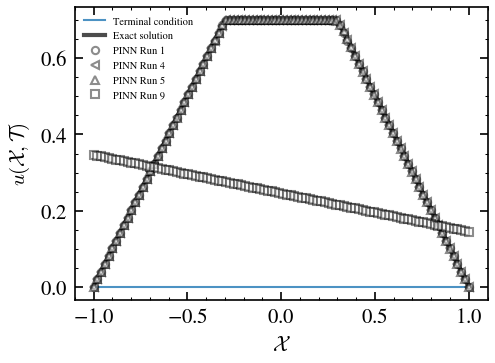

In [8]:

# ------------------------------------------------------------
# Predictions from 10 independent runs
# ------------------------------------------------------------
idx = [1,4,5,9]
# Collect predictions
u_runs = [u_1, u_4, u_5,
          u_9]

# 10 distinct markers
markers = ['o', '<', '^', 's']
        #    'P', 'X', '<', '>', '*']

# ------------------------------------------------------------
# Reference solutions
# ------------------------------------------------------------
plt.plot(
    x,
    0*x,
    '-',
    color='tab:blue',
    linewidth=1,
    alpha=0.8,
    label='Terminal condition',
    zorder=1
)

plt.plot(
    x,
    u_exact,
    '-',
    color='black',
    linewidth=2,
    alpha=0.7,
    label='Exact solution',
    zorder=2
)

# ------------------------------------------------------------
# PINN predictions
# ------------------------------------------------------------
for run_idx, u_pred in enumerate(u_runs):

    plt.plot(
        x,
        u_pred,
        markers[run_idx],
        mfc='white',
        mec='black',
        color='green',
        linestyle='none',
        markersize=3.5,
        alpha=0.45,
        label=f'PINN Run {idx[run_idx]}',
        zorder=3
    )

# ------------------------------------------------------------
# Labels / legend
# ------------------------------------------------------------
plt.xlabel('$\\mathcal{X}$')
plt.ylabel('$u(\\mathcal{X}, \\mathcal{T})$')

plt.legend(fontsize=5, ncol=1, loc='upper left')

# ------------------------------------------------------------
# JCP-style formatting
# ------------------------------------------------------------
ax = plt.gca()

ax.tick_params(
    direction='in',
    length=4,
    width=0.8
)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()

plt.savefig("./figs/solution0.3eikonal.pdf")

plt.show()




In [6]:
from tabulate import tabulate

# Assume x, u (reference), u_1, u_2 are already defined as numpy arrays
# dx = x[1] - x[0]

def compute_norms(u_pred, u_ref):
    err = np.abs(u_pred - u_ref)
    L1   = np.mean(err) 
    L2   = np.sqrt(np.mean((u_pred - u_ref)**2))   
    Linf = np.max(err)
    return L1, L2, Linf

# Compute errors
L1_1, L2_1, Linf_1 = compute_norms(u_1, u_exact.flatten())
L1_2, L2_2, Linf_2 = compute_norms(u_2, u_exact.flatten())
L1_3, L2_3, Linf_3 = compute_norms(u_3, u_exact.flatten())
L1_4, L2_4, Linf_4 = compute_norms(u_4, u_exact.flatten())
L1_5, L2_5, Linf_5 = compute_norms(u_5, u_exact.flatten())
L1_6, L2_6, Linf_6 = compute_norms(u_6, u_exact.flatten())
L1_7, L2_7, Linf_7 = compute_norms(u_7, u_exact.flatten())
L1_8, L2_8, Linf_8 = compute_norms(u_8, u_exact.flatten())
L1_9, L2_9, Linf_9 = compute_norms(u_9, u_exact.flatten())
L1_10, L2_10, Linf_10 = compute_norms(u_10, u_exact.flatten())

table = [
    ["PINN Run 1", f"{L1_1:.2e}", f"{L2_1:.2e}", f"{Linf_1:.2e}"],
    ["PINN Run 2", f"{L1_2:.2e}", f"{L2_2:.2e}", f"{Linf_2:.2e}"],
    ["PINN Run 3", f"{L1_3:.2e}", f"{L2_3:.2e}", f"{Linf_3:.2e}"],
    ["PINN Run 4", f"{L1_4:.2e}", f"{L2_4:.2e}", f"{Linf_4:.2e}"],
    ["PINN Run 5", f"{L1_5:.2e}", f"{L2_5:.2e}", f"{Linf_5:.2e}"],
    ["PINN Run 6", f"{L1_6:.2e}", f"{L2_6:.2e}", f"{Linf_6:.2e}"],
    ["PINN Run 7", f"{L1_7:.2e}", f"{L2_7:.2e}", f"{Linf_7:.2e}"],
    ["PINN Run 8", f"{L1_8:.2e}", f"{L2_8:.2e}", f"{Linf_8:.2e}"],
    ["PINN Run 9", f"{L1_9:.2e}", f"{L2_9:.2e}", f"{Linf_9:.2e}"],
    ["PINN Run 10", f"{L1_10:.2e}", f"{L2_10:.2e}", f"{Linf_10:.2e}"],
]
print("Eikonal equation")
print(tabulate(table, headers=["Method", "L¹ Error", "L² Error", "L∞ Error"], 
               tablefmt="github"))

Eikonal equation
| Method      |   L¹ Error |   L² Error |   L∞ Error |
|-------------|------------|------------|------------|
| PINN Run 1  |   2.12e-05 |   3.85e-05 |   7.04e-05 |
| PINN Run 2  |   0.000103 |   0.000114 |   0.000189 |
| PINN Run 3  |   4.58e-05 |   6.4e-05  |   0.000182 |
| PINN Run 4  |   0.000126 |   0.000334 |   0.00261  |
| PINN Run 5  |   0.000274 |   0.000707 |   0.0048   |
| PINN Run 6  |   3.67e-05 |   4.87e-05 |   0.000118 |
| PINN Run 7  |   4.93e-05 |   6.66e-05 |   0.000114 |
| PINN Run 8  |   6.05e-05 |   7.47e-05 |   0.000125 |
| PINN Run 9  |   0.275    |   0.318    |   0.484    |
| PINN Run 10 |   7.86e-05 |   0.000115 |   0.000312 |
